# Neural Networks and Deep Learning — Code-First Study Notebook

This notebook follows the dependency chain:

**NumPy shapes → broadcasting → binary classification → logistic regression → loss → derivatives → gradient descent → vectorization → neural-network basics.**

Work actively:
1. Run a cell.
2. Predict its output before reading it.
3. Change one variable or shape.
4. Explain the result in one sentence.


## 1. Jupyter Notebook essentials

- `Shift + Enter`: run a cell and move down.
- `Ctrl/Cmd + Enter`: run a cell and stay.
- `Esc`, then `A` / `B`: insert a cell above / below.
- Restart the kernel before a final clean run.
- Keep notes in Markdown cells and experiments in code cells.

A good notebook has small cells: one idea, one check, one conclusion.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7) #* Random values 


## 2. NumPy vectors, matrices, shapes, and broadcasting

Convention used throughout this notebook:

- `X.shape == (n_features, m_examples)`
- `Y.shape == (1, m_examples)`
- Each **column** of `X` is one example.

This convention makes vectorized math clean.


In [5]:
# Vectors and matrices
x = np.array([[1.0], [2.0], [3.0]])     # column vector, shape (3, 1)
w = np.array([[0.2], [-0.1], [0.4]])    # column vector, shape (3, 1)
X_demo = np.array([[1., 4., 7.],
                   [2., 5., 8.],
                   [3., 6., 9.]])      # 3 features x 3 examples

print("x shape:", x.shape)
print("X_demo shape:", X_demo.shape)
print("w.T @ x =", w.T @ x)             # dot product, shape (1, 1)

# Broadcasting: b is automatically copied across all example columns
b = 0.5
Z_demo = w.T @ X_demo + b #* Dot product plus bias
print("Z_demo:", Z_demo, "shape:", Z_demo.shape)


x shape: (3, 1)
X_demo shape: (3, 3)
w.T @ x = [[1.2]]
Z_demo: [[1.7 3.2 4.7]] shape: (1, 3)


### Shape rule worth memorizing

For logistic regression:

$$X \in \mathbb{R}^{n_x \times m}, \quad w \in \mathbb{R}^{n_x \times 1}, \quad b \in \mathbb{R}$$

$$Z = w^T X + b \in \mathbb{R}^{1 \times m}$$

Here, `b` broadcasts across the `m` columns.

## 3. Binary classification and logistic regression

A binary classifier predicts a probability:

$$a = P(y = 1 \mid x)$$

Logistic regression computes:

$$z = w^T x + b, \qquad a = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Use a threshold such as 0.5 to convert probability into a class label.

In [6]:
def sigmoid(z):
    # Clipping prevents overflow for unusually large-magnitude values.
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

z_values = np.array([[-4., -1., 0., 1., 4.]])
print(sigmoid(z_values))


[[0.018  0.2689 0.5    0.7311 0.982 ]]


## 4. Cost function

For one example, binary cross-entropy loss is:

$$L(a, y) = -\big(y \log(a) + (1 - y) \log(1 - a)\big)$$

For `m` examples:

$$J = \frac{1}{m} \sum_{i=1}^{m} L^{(i)}$$

Why this loss? It heavily penalizes confident wrong predictions.

In [7]:
def binary_cross_entropy(A, Y):
    eps = 1e-12
    A = np.clip(A, eps, 1 - eps)
    return -np.mean(Y * np.log(A) + (1 - Y) * np.log(1 - A))

A_example = np.array([[0.99, 0.01, 0.70]])
Y_example = np.array([[1.,   1.,   0.]])
print("Loss:", binary_cross_entropy(A_example, Y_example))


Loss: 1.9397311087225093


## 5. The key derivative: $dL/dz$

Start with:

$$L = -\left(y \log(a) + (1 - y) \log(1 - a)\right), \quad a = \sigma(z)$$

Then:

$$\frac{dL}{da} = -\frac{y}{a} + \frac{1 - y}{1 - a}$$

and:

$$\frac{da}{dz} = a(1 - a)$$

Multiplying and simplifying gives the result to remember:

$$\boxed{\frac{dL}{dz} = a - y}$$

For a batch, this becomes `dZ = A - Y`.

This cancellation is why sigmoid + binary cross-entropy is especially convenient.

## 6. Computation graph

For one batch:

$$X \to Z = w^T X + b \to A = \sigma(Z) \to J = \text{loss}(A, Y)$$

Forward pass computes values. Backward pass applies the chain rule from right to left.

With $X$ shaped $(n_x, m)$:

$$dZ = A - Y$$

$$dw = \frac{1}{m} X \, dZ^T$$

$$db = \frac{1}{m} \sum dZ$$

## 7. Build logistic regression from scratch (fully vectorized)

In [8]:
class LogisticRegressionNumpy:
    def __init__(self, learning_rate=0.1, iterations=2000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.w = None
        self.b = None
        self.history = []

    def forward(self, X):
        Z = self.w.T @ X + self.b
        return sigmoid(Z)

    def fit(self, X, Y, report_every=200):
        # X: (n_features, m), Y: (1, m)
        n_features = X.shape[0]
        m = X.shape[1]
        self.w = np.zeros((n_features, 1))
        self.b = 0.0
        self.history = []

        for i in range(self.iterations):
            A = self.forward(X)
            cost = binary_cross_entropy(A, Y)

            # Backpropagation
            dZ = A - Y
            dw = (X @ dZ.T) / m
            db = np.sum(dZ) / m

            # Gradient descent update
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            if i % report_every == 0 or i == self.iterations - 1:
                self.history.append((i, cost))
        return self

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, Y):
        return np.mean(self.predict(X) == Y)


## 8. Train it on a synthetic two-class dataset

In [9]:
# Create a linearly separable dataset
m_per_class = 200
X0 = rng.normal(loc=[-1.3, -1.0], scale=0.75, size=(m_per_class, 2))
X1 = rng.normal(loc=[ 1.2,  1.0], scale=0.75, size=(m_per_class, 2))

X_rows = np.vstack([X0, X1])
Y_rows = np.concatenate([np.zeros(m_per_class), np.ones(m_per_class)])

# Shuffle, then convert to course convention: features x examples
perm = rng.permutation(X_rows.shape[0])
X_rows, Y_rows = X_rows[perm], Y_rows[perm]
X = X_rows.T
Y = Y_rows.reshape(1, -1)

model = LogisticRegressionNumpy(learning_rate=0.12, iterations=2000)
model.fit(X, Y)

print("weights:", model.w.ravel())
print("bias:", model.b)
print("training accuracy:", f"{model.accuracy(X, Y):.3f}")
print("initial and final recorded costs:", model.history[0], model.history[-1])


weights: [4.1481 2.6979]
bias: 0.4449270722926167
training accuracy: 0.995
initial and final recorded costs: (0, np.float64(0.6931471805599452)) (1999, np.float64(0.023657194334348784))


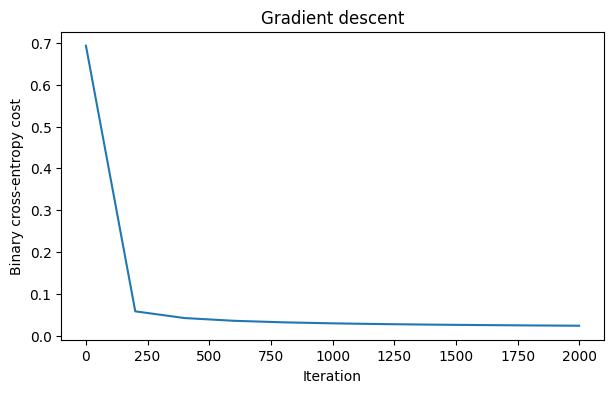

In [10]:
# Plot loss descent
iterations, costs = zip(*model.history)
plt.figure(figsize=(7, 4))
plt.plot(iterations, costs)
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy cost")
plt.title("Gradient descent")
plt.show()


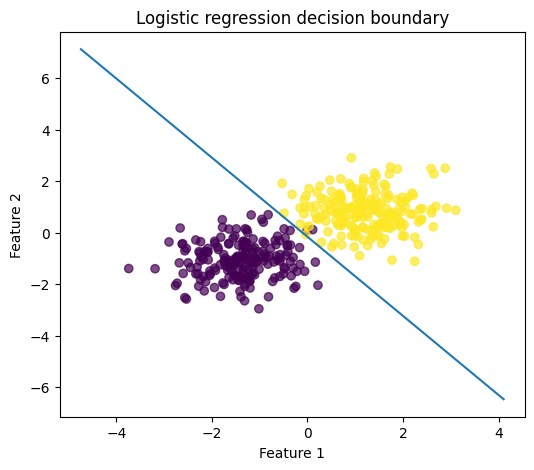

In [11]:
# Visualize the learned decision boundary
plt.figure(figsize=(6, 5))
plt.scatter(X_rows[:, 0], X_rows[:, 1], c=Y_rows, alpha=0.7)

x_axis = np.linspace(X_rows[:, 0].min() - 1, X_rows[:, 0].max() + 1, 100)
if abs(model.w[1, 0]) > 1e-12:
    y_axis = -(model.w[0, 0] * x_axis + model.b) / model.w[1, 0]
    plt.plot(x_axis, y_axis)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic regression decision boundary")
plt.show()


## 9. Vectorization: loops versus matrix math

Avoid looping over training examples. This:

```python
Z = w.T @ X + b
```

computes all `m` examples at once. It is shorter, less error-prone, and far faster in NumPy.


In [12]:
# Equivalent operations: loop form vs vectorized form
w_demo = np.array([[0.2], [-0.1]])
b_demo = 0.5
X_small = X[:, :5]

loop_values = np.array([[float(w_demo.T @ X_small[:, i:i+1] + b_demo)
                         for i in range(X_small.shape[1])]])
vectorized_values = w_demo.T @ X_small + b_demo

print("same result?", np.allclose(loop_values, vectorized_values))
print(vectorized_values)


same result? True
[[0.9353 0.3773 0.313  0.4932 0.3838]]


C:\Users\User\AppData\Local\Temp\ipykernel_15820\1800711198.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loop_values = np.array([[float(w_demo.T @ X_small[:, i:i+1] + b_demo)


## 10. Neural-network basics: add a hidden layer

A shallow neural network changes logistic regression from one linear boundary into a nonlinear model:

$$Z^{[1]} = W^{[1]} X + b^{[1]}$$

$$A^{[1]} = \text{ReLU}(Z^{[1]})$$

$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}$$

$$A^{[2]} = \sigma(Z^{[2]})$$

The output-layer gradient is still:

$$dZ^{[2]} = A^{[2]} - Y$$

In [13]:
def relu(Z):
    return np.maximum(0, Z)

def train_two_layer_network(X, Y, hidden_units=6, learning_rate=0.1, iterations=3000):
    n_x, m = X.shape
    params = {
        "W1": rng.normal(0, np.sqrt(2 / n_x), size=(hidden_units, n_x)),
        "b1": np.zeros((hidden_units, 1)),
        "W2": rng.normal(0, np.sqrt(2 / hidden_units), size=(1, hidden_units)),
        "b2": np.zeros((1, 1)),
    }
    costs = []

    for i in range(iterations):
        # Forward pass
        Z1 = params["W1"] @ X + params["b1"]
        A1 = relu(Z1)
        Z2 = params["W2"] @ A1 + params["b2"]
        A2 = sigmoid(Z2)

        # Backward pass
        dZ2 = A2 - Y
        dW2 = (dZ2 @ A1.T) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m
        dA1 = params["W2"].T @ dZ2
        dZ1 = dA1 * (Z1 > 0)
        dW1 = (dZ1 @ X.T) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m

        # Update
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1
        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2

        if i % 300 == 0 or i == iterations - 1:
            costs.append((i, binary_cross_entropy(A2, Y)))

    return params, costs

def two_layer_predict(params, X):
    A1 = relu(params["W1"] @ X + params["b1"])
    A2 = sigmoid(params["W2"] @ A1 + params["b2"])
    return (A2 >= 0.5).astype(int)

params, nn_costs = train_two_layer_network(X, Y)
nn_accuracy = np.mean(two_layer_predict(params, X) == Y)
print("two-layer training accuracy:", f"{nn_accuracy:.3f}")
print("initial and final recorded costs:", nn_costs[0], nn_costs[-1])


two-layer training accuracy: 0.993
initial and final recorded costs: (0, np.float64(1.9817367366269858)) (2999, np.float64(0.013736192654368005))


## 11. Checkpoint exercises

Do these without looking at earlier cells:

1. State the shapes of `W1`, `b1`, `W2`, `b2` for `n_x=4`, `n_h=5`, `n_y=1`.
2. Explain why `b` can be added to every example column without a loop.
3. Derive `dL/dz` from the binary cross-entropy and sigmoid formulas.
4. Change the logistic-regression threshold from 0.5 to 0.7. What happens to false positives and false negatives?
5. Add an 80/20 train-test split. Report both accuracies.
6. Replace ReLU with `tanh`; update the derivative accordingly.
7. Make a nonlinear “circle” dataset. Compare logistic regression and the 2-layer model.

A solution is useful only after you have attempted it.
